# Modeling (Jordan Blackman)

Using Nutrition Information to Classify Brand Tier (Premium Foods)

Mia Arnold - Jordan Blackman - Allen Ros

Shirley Marcos School of Engineering, University of San Diego

ADS-502 Applied Data Mining

# Goals

1. Data type transformation, remove features that would lead to overfitting, test train split, SMOTENC(nominal and continuous), Encoding, and Scaling.

2. Establish Baseline Model and evaluation metrics

3. Train initial models, tune hyperparameters (max leaf, minobservations, C for regularization), explore cost matrices, and explore bagging and boosting

4. Compare all models across multiple metrics beyond accuracy

Models to explore: Baseline (Majority Class), Naive Bayes, Decision Tree (CART, C5.0), kNN Classifier, Logistic Regression, SVC (Linear), SVC (RBF), SVC (Polynamial), SVC (Sigmoid), Random Forest Classifier (with bagging and boosting), XGBoost, Adaboost, and Neural Network.

The winning model I want to focus on is XGBoost

# Data Type Transformation and Removing Overfitting Features

In [1]:
# import the necessary packages
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv("food_menu_nutrition_dataset.csv")

# Transformation, encoding, and scaling not needed for XGBoost because its a tree based model

# set up items that are not being used for training models
items_to_drop = ['item_name', 'city', 'brand_name',
                 'brand_tier']

# get dependent and independent variables
Y = (df['brand_tier'] == 'premium').astype(int)
X = df.drop(columns=items_to_drop)

# view the data
df.head().T

,0,1,2,3,4
item_name,Veggie Sub,Waffles with Syrup,Grilled Chicken Salad,Waffles with Syrup,Chocolate Brownie
item_category,Sandwich,Dessert,Salad,Dessert,Dessert
item_subcategory,Veg,Veg,Non-Veg,Veg,Veg
brand_name,Five Guys,KFC,Domino's,Five Guys,Subway
brand_tier,mid,budget,budget,mid,budget
country,UK,USA,Canada,USA,USA
city,London,Austin,Toronto,Chicago,Chicago
city_tier,metro,tier-2,metro,metro,metro
price_usd_normalized,8.66,2.78,5.77,8.47,2.79
serving_size_g,224.9,151.7,294.1,87.7,125.4


# Test Train Split

In [2]:
# test train split with random state and stratification
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

# SMOTE

In [3]:
# convert categorical columns to category
cat_cols = ['item_category', 'item_subcategory', 'country', 'city_tier']
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [4]:
# Oversample the minority class (Premium)
from imblearn.over_sampling import SMOTENC

# find categorical indices
cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

# show data before SMOTE
print("Before SMOTE")
print(Y_train.value_counts())

# conduct SMOTE, using random state, only on the training data
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train_smote, Y_train_smote = smote_nc.fit_resample(X_train, Y_train)

# show data after SMOTE to check balance.
print("After SMOTE:")
print(Y_train_smote.value_counts())

Before SMOTE
brand_tier
0    5404
1     596
Name: count, dtype: int64
After SMOTE:
brand_tier
0    5404
1    5404
Name: count, dtype: int64


# Establish Evaluation Function

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# define a reusable function to calculate evaluation metrics for all models


def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model", verbose=True):

    # set up calculations
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    roc_auc = None
    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)

    # print calculations
    if verbose:
        print(f"--- {model_name} Evaluation ---")
        print(f"Accuracy:    {acc:.4f}")
        print(f"Precision:   {prec:.4f}")
        print(f"Recall:      {rec:.4f} (Sensitivity)")
        print(f"Specificity: {specificity:.4f}")
        print(f"F1-Score:    {f1:.4f}")

        if roc_auc is not None:
            print(f"ROC AUC:     {roc_auc:.4f}")

        print("-" * 30 + "\n")

        # plot confusion matrix
        fig, ax = plt.subplots(figsize=(4, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"Confusion Matrix: {model_name}")
        plt.tight_layout()
        plt.show()

    # save variables per model
    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc
    }

# Establish Reusable Modeling Function

In [6]:
# establish a function trains and evaluates all models
def train_and_evaluate(model, x_train, y_train, x_test, y_test, model_name, verbose=True):
    # fit
    model.fit(x_train, y_train)
    # predict using test
    y_pred = model.predict(x_test)

    # get y predictions data
    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]

    # run previously established function to evaluate model performance
    metrics = evaluate_model(y_test, y_pred, y_prob, model_name, verbose)

    # return the metrics
    return metrics

# Establish Baseline Model

--- Baseline (Majority Class) Evaluation ---
Accuracy:    0.9007
Precision:   0.0000
Recall:      0.0000 (Sensitivity)
Specificity: 1.0000
F1-Score:    0.0000
ROC AUC:     0.5000
------------------------------



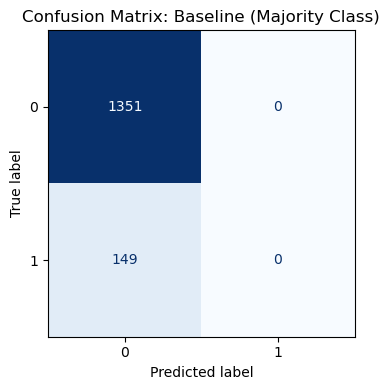

In [7]:
# dummy model always predicts the majority class
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="constant", constant=0)

baseline_metrics = train_and_evaluate(
    baseline,
    X_train_smote,
    Y_train_smote,
    X_test,
    Y_test,
    model_name="Baseline (Majority Class)"
)

# Train Initial Models

--- XGBoost Evaluation ---
Accuracy:    0.9520
Precision:   0.7127
Recall:      0.8658 (Sensitivity)
Specificity: 0.9615
F1-Score:    0.7818
ROC AUC:     0.9827
------------------------------



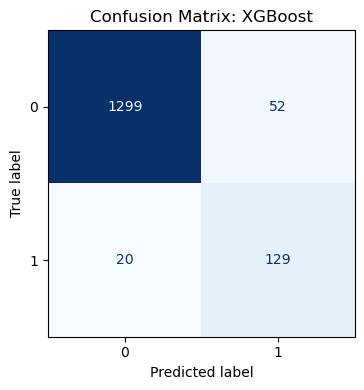

In [8]:
# XGBoost
from xgboost import XGBClassifier

# start with reasonable settings, tune later
xgb_model = XGBClassifier(
    n_estimators=100,  # number of trees to build
    learning_rate=0.1,  # how quickly the model adapts to training data
    max_depth=5,  # max depth of trees
    eval_metric='logloss',  # metric to optimize with
    enable_categorical=True,  # handle categoricals without one hot encoding
    random_state=42  # set for reproduceability
)

# evaluate XGBoost Model
xgb_metrics = train_and_evaluate(
    xgb_model,
    X_train_smote,
    Y_train_smote,
    X_test,
    Y_test,
    model_name="XGBoost"
)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'xgb__colsample_bytree': np.float64(0.7394663949166917), 'xgb__learning_rate': np.float64(0.03885296532742623), 'xgb__max_depth': 3, 'xgb__n_estimators': 210, 'xgb__subsample': np.float64(0.759028808435009)}
--- Tuned XGBoost Evaluation ---
Accuracy:    0.9347
Precision:   0.6154
Recall:      0.9128 (Sensitivity)
Specificity: 0.9371
F1-Score:    0.7351
ROC AUC:     0.9809
------------------------------



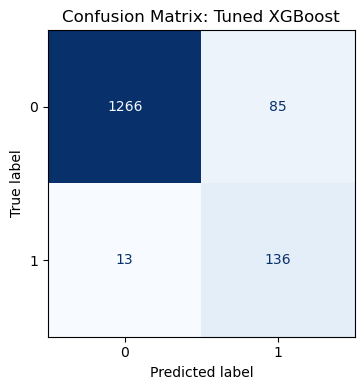

In [9]:
# XGBoost with tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from imblearn.pipeline import Pipeline

# set up model
xgb_model = XGBClassifier(
    random_state=42,  # set for reproduceability
    eval_metric='logloss',  # metric to optimize with
    enable_categorical=True  # handle categoricals without one hot encoding
)

pipeline = Pipeline(steps=[
    ('smote', smote_nc),
    ('xgb', xgb_model)
])

# set up parameters
param_dist = {
    # how quickly the model adapts to training data
    'xgb__learning_rate': uniform(0.01, 0.3),
    'xgb__max_depth': randint(3, 7),  # max depth of trees
    'xgb__n_estimators': randint(50, 300),  # number of trees to build
    # fraction of training data sampled to grow a tree
    'xgb__subsample': uniform(0.6, 0.4),
    # fraction of features randomly chosen for each tree
    'xgb__colsample_bytree': uniform(0.6, 0.4)
}

# search for best parameters
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=50,  # number of times to run the parameter combinations
    scoring='roc_auc',  # scoring based on ROC AUC
    cv=3,  # 3 fold cross validated
    verbose=1,  # print what is being fit
    random_state=42,  # set for reproduceability
    n_jobs=-1  # speed up search
)

# fit the random search
random_search.fit(X_train, Y_train)

# print best parameters
print(f"Best Parameters: {random_search.best_params_}")

# train and evaluate tuned XGBoost model
best_xgb = random_search.best_estimator_

tuned_xgb_metrics = train_and_evaluate(
    best_xgb,
    X_train,
    Y_train,
    X_test,
    Y_test,
    model_name="Tuned XGBoost"
)

Optimal Threshold for F2-Score: 0.5972
--- Tuned XGBoost (Optimized Threshold) Evaluation ---
Accuracy:    0.9553
Precision:   0.7303
Recall:      0.8725 (Sensitivity)
Specificity: 0.9645
F1-Score:    0.7951
ROC AUC:     0.9809
------------------------------



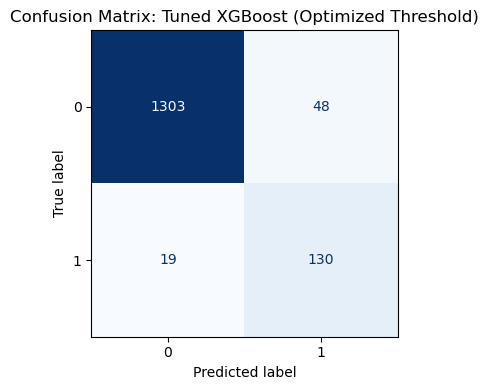

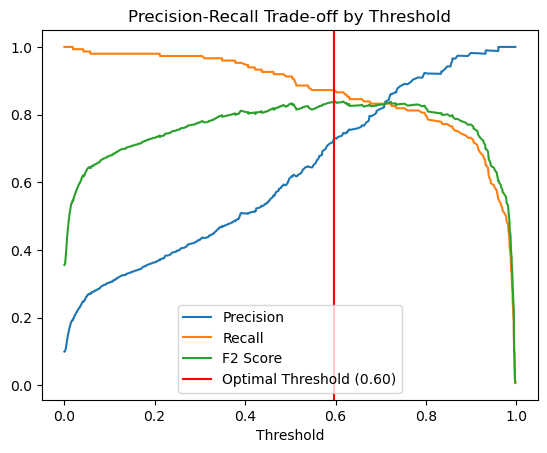

In [10]:
# show precision recall tradeoff with f2 score
from sklearn.metrics import precision_recall_curve

# get predicted probabilities on the test set
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

# compute precision, recall, and thresholds across the curve
precisions, recalls, thresholds = precision_recall_curve(Y_test, y_prob_tuned)
# f2 balanced precision and recall better in this scenario
f2_scores = 5 * (precisions * recalls) / ((4 * precisions) + recalls)

# find the optimal threshold that maximizes f2 score
optimal_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold for F2-Score: {optimal_threshold:.4f}")

# apply the optimal threshold to make binary predictions on the test set
y_pred_optimized = (y_prob_tuned >= optimal_threshold).astype(int)

# evaluate the model using your custom function with the new threshold
optimized_xgb_metrics = evaluate_model(
    Y_test,
    y_pred_optimized,
    y_prob_tuned,
    model_name="Tuned XGBoost (Optimized Threshold)",
    verbose=True
)

# plot precision, recall, and f2 scores by threshold
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f2_scores[:-1], label="F2 Score")
plt.axvline(
    x=optimal_threshold,
    color='red',
    label=f'Optimal Threshold ({optimal_threshold:.2f})'
)
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision-Recall Trade-off by Threshold")
plt.show()

# Compare Models

In [11]:
# Compare all model results
model_results = [val for name, val in globals().items(
) if 'metrics' in name and isinstance(val, dict)]

# Convert to DataFrame
results_df = pd.DataFrame(model_results)

# Set the 'model' column as the index for better readability
results_df.set_index('model', inplace=True)

# Display the table
results_df.sort_values(by='f1_score', ascending=False). round(3)

,accuracy,precision,recall,specificity,f1_score,roc_auc
model,,,,,,
Tuned XGBoost (Optimized Threshold),0.955,0.730,0.872,0.964,0.795,0.981
XGBoost,0.952,0.713,0.866,0.962,0.782,0.983
Tuned XGBoost,0.935,0.615,0.913,0.937,0.735,0.981
Baseline (Majority Class),0.901,0.000,0.000,1.000,0.000,0.500


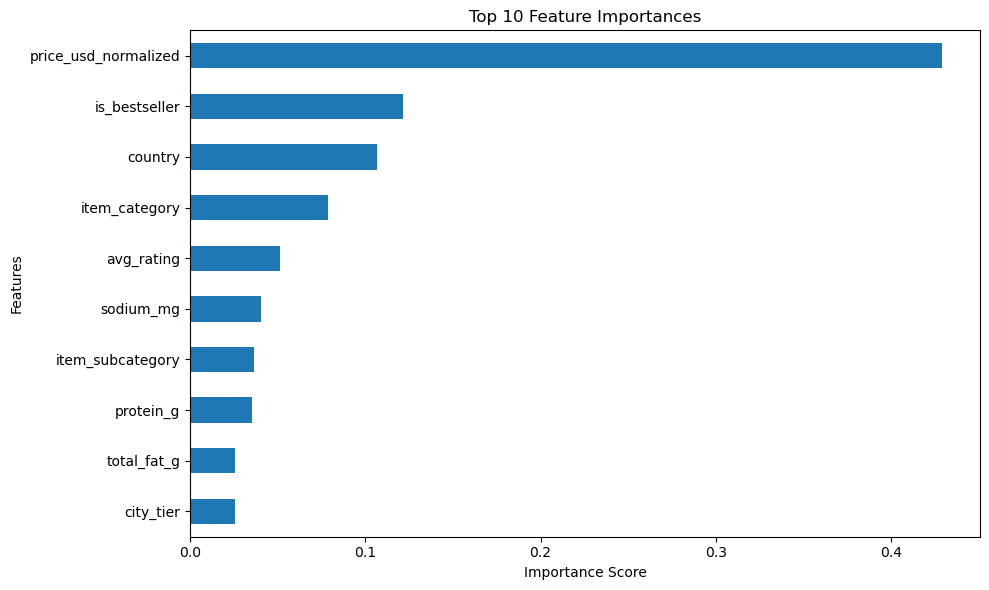

In [12]:
# Get feature importance
importances = best_xgb.named_steps['xgb'].feature_importances_
feature_names = X_train.columns
feat_imp = pd.Series(
    importances, index=feature_names).sort_values(ascending=False)

# plot top 10 feature importance
plt.figure(figsize=(10, 6))
feat_imp.head(10).sort_values(ascending=True).plot(
    kind='barh', title="Top 10 Feature Importances", )
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [13]:
print(dict(enumerate(X_train['item_category'].cat.categories)))
print(dict(enumerate(X_train['item_subcategory'].cat.categories)))
print(dict(enumerate(X_train['country'].cat.categories)))
print(dict(enumerate(X_train['city_tier'].cat.categories)))

{0: 'Burger', 1: 'Dessert', 2: 'Drink', 3: 'Pizza', 4: 'Rice/Bowl', 5: 'Salad', 6: 'Sandwich', 7: 'Sides'}
{0: 'Non-Veg', 1: 'Veg', 2: 'Vegan'}
{0: 'Australia', 1: 'Canada', 2: 'India', 3: 'UK', 4: 'USA'}
{0: 'metro', 1: 'tier-2', 2: 'tier-3'}


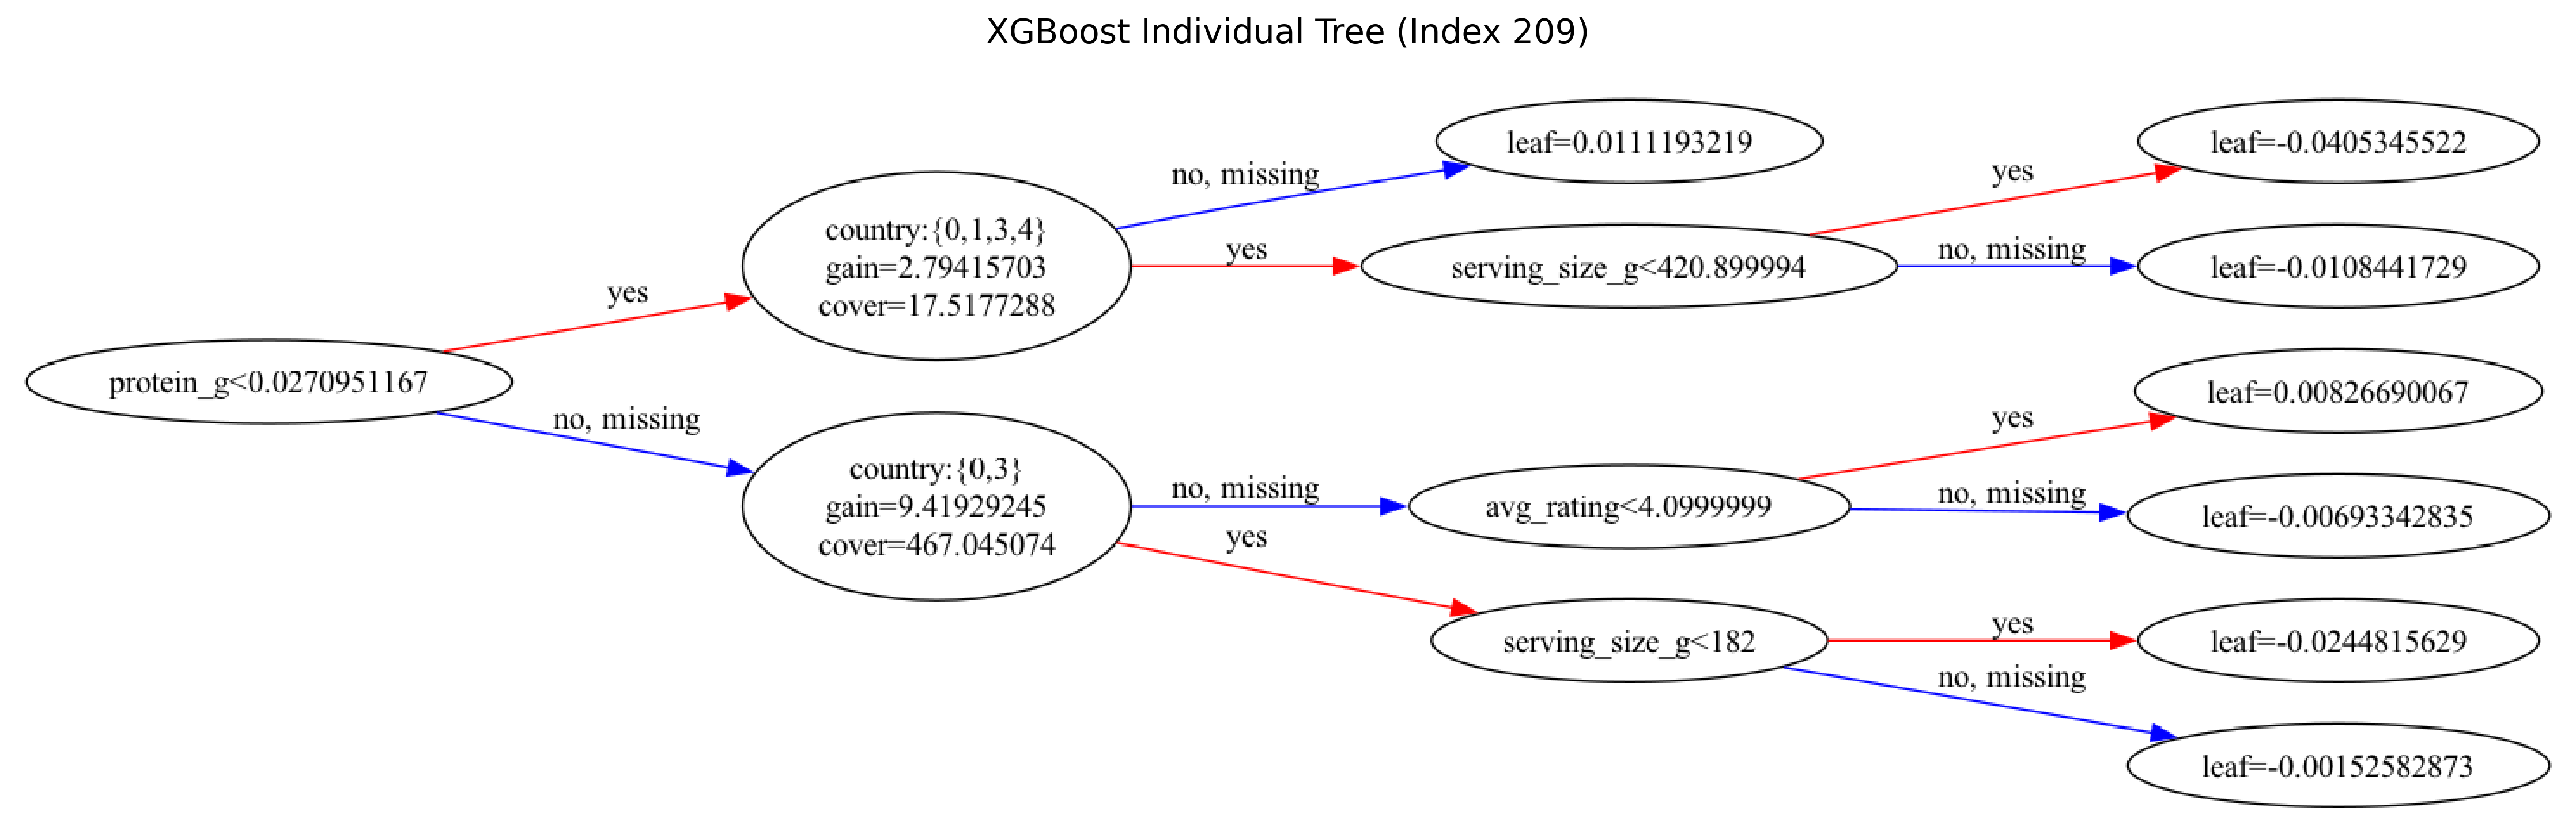

In [14]:
from xgboost import plot_tree

# increase DPI and figure size
fig, ax = plt.subplots(figsize=(15, 10), dpi=300)

# plot tree
plot_tree(best_xgb.named_steps['xgb'], tree_idx=209,
          ax=ax, rankdir='LR')
plt.title("XGBoost Individual Tree (Index 209)", fontsize=14, pad=20)
plt.tight_layout()

# save and show tree
plt.savefig("xgboost_tree_high_res.pdf",
            format="pdf", bbox_inches="tight")

plt.show()

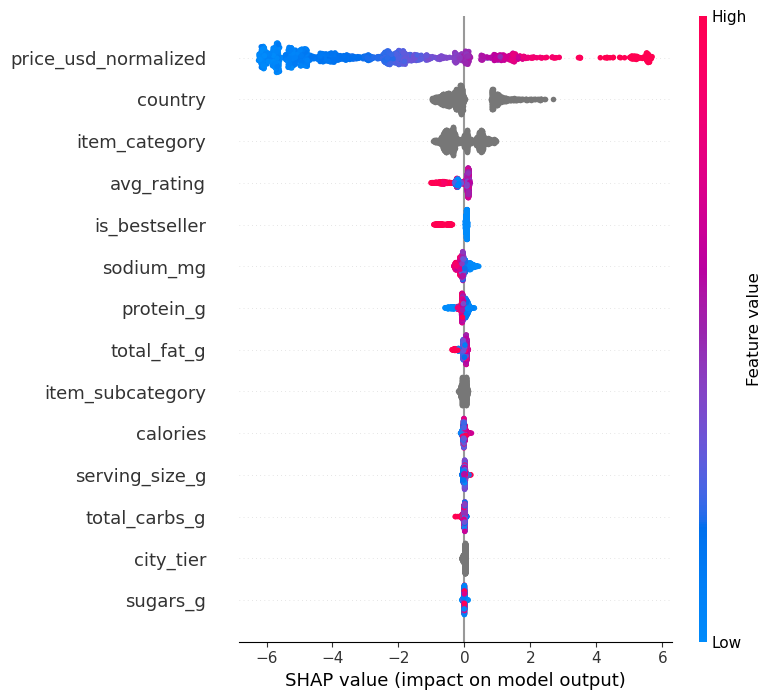

In [15]:
import shap

# set up javascript visualizations
shap.initjs()

# create a tree explainer for the XGBoost model
explainer = shap.TreeExplainer(best_xgb.named_steps['xgb'])

# calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# generate the summary plot
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)

# Data Type Transformation and Removing Overfitting Features

In [16]:
# import the necessary packages
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv("food_menu_nutrition_dataset.csv")

# log price, protein, and sugars to handle significant skew
df['log_price_usd_normalized'] = np.log1p(df['price_usd_normalized'])
df['log_protein_g'] = np.log1p(df['protein_g'])
df['log_sugars_g'] = np.log1p(df['sugars_g'])

# square root serving size, calories, fat, carbs, sodium to handle small skew
df['sqrt_serving_size_g'] = np.sqrt(df['serving_size_g'])
df['sqrt_calories'] = np.sqrt(df['calories'])
df['sqrt_total_fat_g'] = np.sqrt(df['total_fat_g'])
df['sqrt_total_carbs_g'] = np.sqrt(df['total_carbs_g'])
df['sqrt_sodium_mg'] = np.sqrt(df['sodium_mg'])

# flip average rating to handle left skew, units are flipped
reflect_constant = df['avg_rating'].max() + 1
df['trans_avg_rating'] = np.sqrt(reflect_constant - df['avg_rating'])

# is_bestseller is the only numerical variable left alone

# drop all original columns that were transformed
df = df.drop(columns=['price_usd_normalized', 'protein_g', 'sugars_g',
                      'serving_size_g', 'calories', 'total_fat_g',
                      'total_carbs_g', 'sodium_mg', 'avg_rating'])

# set up items that are nto being used for training models
items_to_drop = ['item_name', 'city', 'brand_name',
                 'brand_tier']

# get dependent and independent variables
Y = (df['brand_tier'] == 'premium').astype(int)
X = df.drop(columns=items_to_drop)

# view the data
df.head().T

,0,1,2,3,4
item_name,Veggie Sub,Waffles with Syrup,Grilled Chicken Salad,Waffles with Syrup,Chocolate Brownie
item_category,Sandwich,Dessert,Salad,Dessert,Dessert
item_subcategory,Veg,Veg,Non-Veg,Veg,Veg
brand_name,Five Guys,KFC,Domino's,Five Guys,Subway
brand_tier,mid,budget,budget,mid,budget
country,UK,USA,Canada,USA,USA
city,London,Austin,Toronto,Chicago,Chicago
city_tier,metro,tier-2,metro,metro,metro
is_bestseller,0,0,0,0,0
log_price_usd_normalized,2.267994,1.329724,1.912501,2.248129,1.332366


# Test Train Split

In [17]:
# test train split with random state and stratification
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

# SMOTE

In [18]:
# Oversample the minority class (Premium)
from imblearn.over_sampling import SMOTENC

cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.drop(
    items_to_drop, errors='ignore').tolist()

cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

print("Before SMOTE")
print(Y_train.value_counts())

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train, Y_train = smote_nc.fit_resample(X_train, Y_train)

print("After SMOTE:")
print(Y_train.value_counts())

Before SMOTE
brand_tier
0    5404
1     596
Name: count, dtype: int64
After SMOTE:
brand_tier
0    5404
1    5404
Name: count, dtype: int64


# Encoding

In [19]:
# encode variables
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# align encoded variables
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns, fill_value=0)

# Scale variables

In [20]:
from sklearn.preprocessing import StandardScaler

# scale variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)

# Logistic Regression

--- Logistic Regression Evaluation ---
Accuracy:    0.9173
Precision:   0.5486
Recall:      0.9463 (Sensitivity)
Specificity: 0.9141
F1-Score:    0.6946
ROC AUC:     0.9842
------------------------------



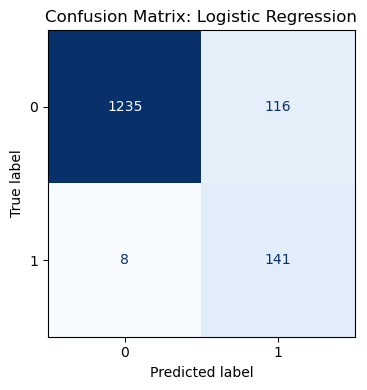

In [21]:
from sklearn.linear_model import LogisticRegression

log_reg_2 = LogisticRegression(random_state=42)

log_reg_2_metrics = train_and_evaluate(
    log_reg_2,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Logistic Regression"

)

# SVC Linear

--- SVC Linear Evaluation ---
Accuracy:    0.9160
Precision:   0.5458
Recall:      0.9195 (Sensitivity)
Specificity: 0.9156
F1-Score:    0.6850
ROC AUC:     0.9815
------------------------------



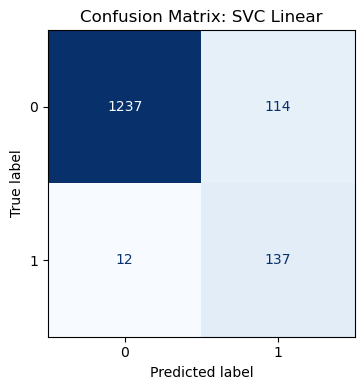

In [22]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

base_svc_linear = SVC(C=0.2, kernel="linear", random_state=42)
svc_linear = CalibratedClassifierCV(base_svc_linear, ensemble=False)

svc_metrics = train_and_evaluate(
    svc_linear,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="SVC Linear"
)
  

# Comparing Model Results

In [23]:
# 1. Compare all model results
model_results = [val for name, val in globals().items(
) if 'metrics' in name and isinstance(val, dict)]

# 2. Convert to DataFrame
results_df = pd.DataFrame(model_results)

# 3. Set the 'model' column as the index for better readability
results_df.set_index('model', inplace=True)

# 4. Display the table
results_df.sort_values(by='f1_score', ascending=False). round(3)

,accuracy,precision,recall,specificity,f1_score,roc_auc
model,,,,,,
Tuned XGBoost (Optimized Threshold),0.955,0.730,0.872,0.964,0.795,0.981
XGBoost,0.952,0.713,0.866,0.962,0.782,0.983
Tuned XGBoost,0.935,0.615,0.913,0.937,0.735,0.981
Logistic Regression,0.917,0.549,0.946,0.914,0.695,0.984
SVC Linear,0.916,0.546,0.919,0.916,0.685,0.981
Baseline (Majority Class),0.901,0.000,0.000,1.000,0.000,0.500


# Explore Hyperparameters and Cost Matrices